# Time-varying Neural Dynamics

**This project is the final project for Brown APMA 1360 Applied Dynamical Systems**

This is the final report for generating required figures.

## Import

In [12]:
# %matplotlib widget
import importlib

import numpy as np
import jPCA
from jPCA.jPCA import JPCA
import matplotlib.pyplot as plt
from jPCA.util import load_churchland_data, plot_projections, preprocess
from jPCA.regression import skew_sym_regress
from utils import plot_3d_projections, bins_for_window, stack_XY_in_window

## Read Data

We are going to use the example data provided by the Churchland group used for original jPCA paper where a monkey performed delayed reaching tasks. The data read in is 

$$X \in \reals^{C \times T \times N}$$

where N is the number of neurons (218), and C is the number of conditions.

In [13]:
path = "exampleData.mat"
data, times = load_churchland_data(path)
times_full_axis = list(times)  # full −50…550 ms axis for full-epoch section below

print(f"Number of conditions: {len(data)}")
print(f"Number of neurons: {data[0].shape[1]}")
print(f"Number of time points: {data[0].shape[0]}")

print(f"Time range: {times[0]} to {times[-1]} ms.")
print(f"Sampling rate: {1 / np.mean(np.diff(times)/1000):.2f} Hz.")

Number of conditions: 108
Number of neurons: 218
Number of time points: 61
Time range: -50 to 550 ms.
Sampling rate: 100.00 Hz.


The data loaded is a list of conditions. There are 108 conditions in total, and for each condition, there is an numpy array of shape `(61, 218)`

Average firing rate across conditions: (61, 218)


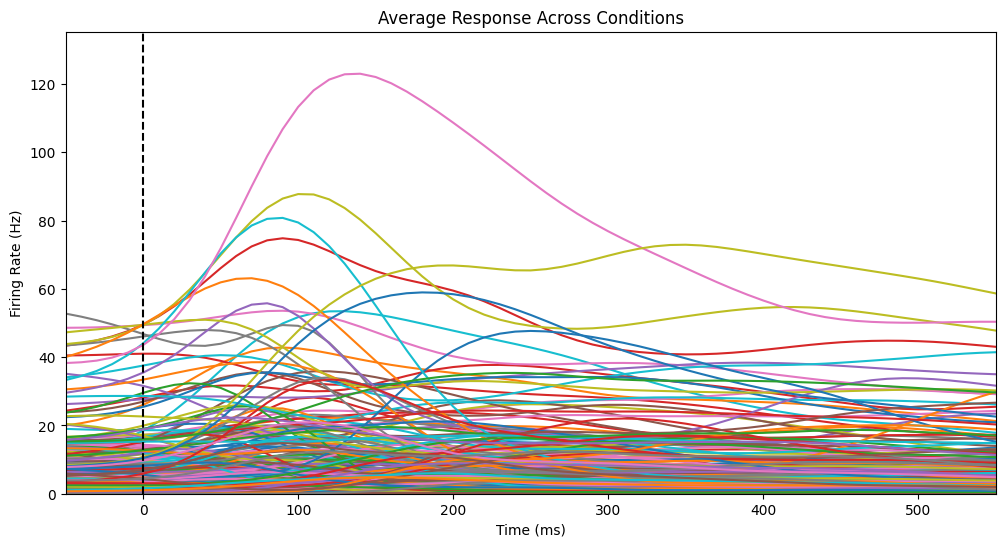

In [14]:
# Plot some data
average_data = np.mean(data, axis=0)
print(f"Average firing rate across conditions: {average_data.shape}")

# Firing rates of each channel
plt.figure(figsize=(12, 6))
plt.plot(times, average_data)
plt.title("Average Response Across Conditions")
plt.xlabel("Time (ms)")
plt.ylabel("Firing Rate (Hz)")
plt.xlim(times[0], times[-1])
plt.ylim(0, np.max(average_data) * 1.1)
plt.axvline(0, color='k', linestyle='--', label='Movement Onset')
plt.show()

## Preprocessing

Preprocessing includes soft normalization, mean subtraction, and PCA. Here we just utilize the preprocessing method in the toolbox.

Data shape after preprocessing: (108, 21, 6)


/Users/emmiefitz-gibbon/Desktop/Time-varyingND/.venv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/emmiefitz-gibbon/Desktop/Time-varyingND/.venv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/emmiefitz-gibbon/Desktop/Time-varyingND/.venv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/emmiefitz-gibbon/Desktop/Time-varyingND/.venv/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/emmiefitz-gibbon/Desktop/Time-varyingND/.venv/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/emmiefitz-gibbon/Desktop/Time-

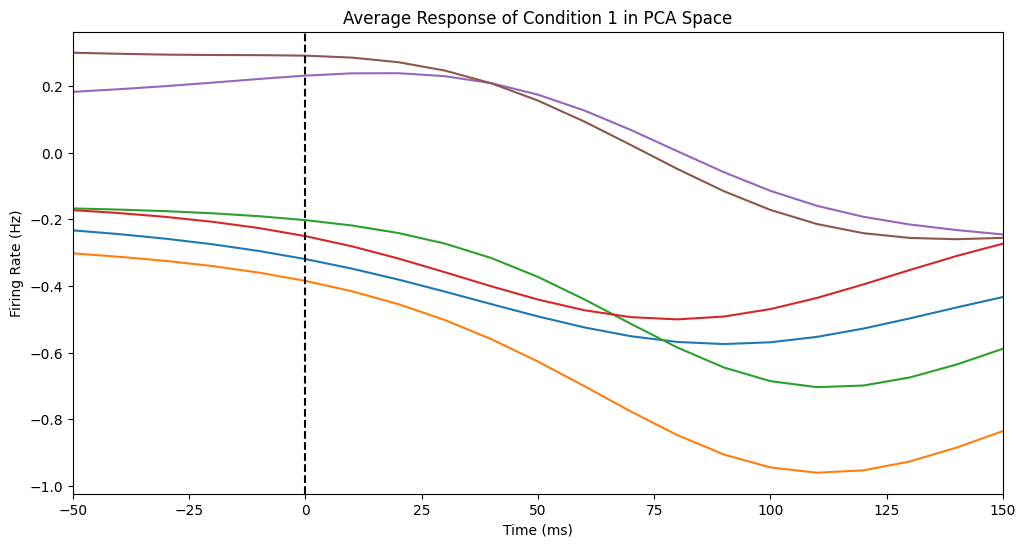

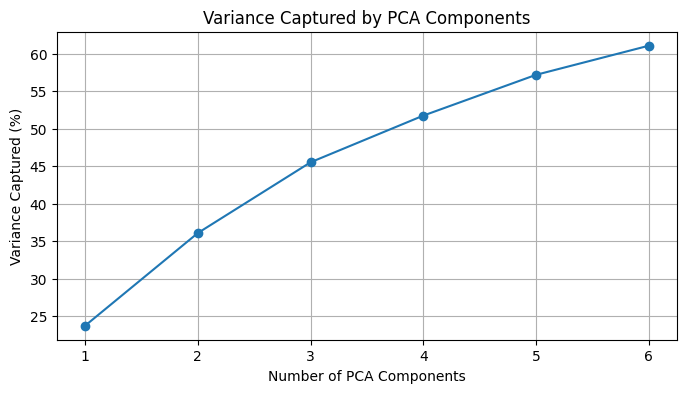

In [15]:
data_list, full_data_var, pca_variance_captured = preprocess(data, times, tstart=-50, tend=150)
times = [t for t in times if -50 <= t <= 150]
data_reduced = np.stack(data_list, axis=0)
print(f"Data shape after preprocessing: {data_reduced.shape}")

plt.figure(figsize=(12, 6))
plt.plot(times, data_list[0])
plt.title("Average Response of Condition 1 in PCA Space")
plt.xlabel("Time (ms)")
plt.ylabel("Firing Rate (Hz)")
plt.xlim(times[0], times[-1])
plt.axvline(0, color='k', linestyle='--', label='Movement Onset')
plt.show()

ratio_captured = pca_variance_captured / full_data_var
ratio_captured_cumsum = np.cumsum(ratio_captured)
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(ratio_captured_cumsum) + 1), ratio_captured_cumsum * 100, marker='o')
plt.title("Variance Captured by PCA Components")
plt.xlabel("Number of PCA Components")
plt.ylabel("Variance Captured (%)")
plt.grid()
plt.show()


## Dynamics in PCA space

We can now visualize the neural dynamics in the PCA space. We are only ploting the top 3 PCs. Note that here's the entire trial from -50 ms to 550 ms.

### Plot the trajectories

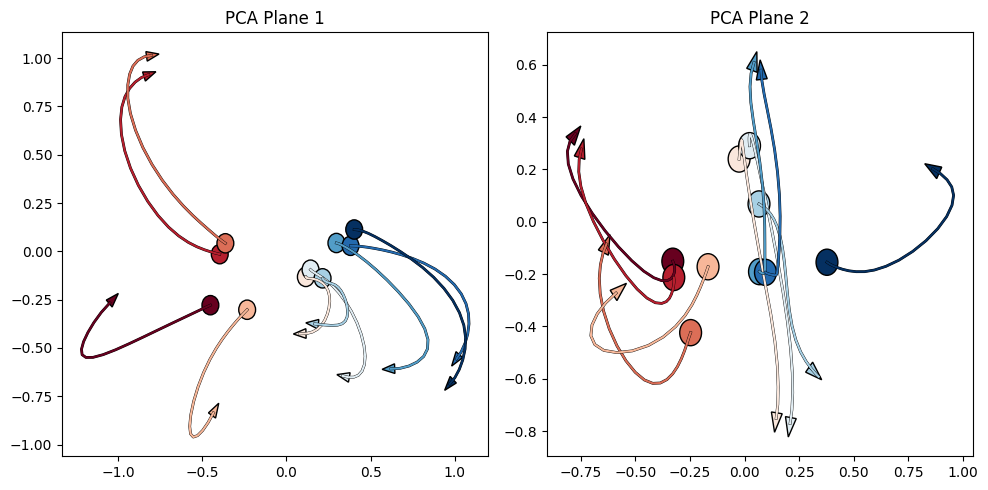

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_projections(data_list[0:10], axis=axes[0], x_idx=0, y_idx=1)
plot_projections(data_list[0:10], axis=axes[1], x_idx=2, y_idx=3)

axes[0].set_title("PCA Plane 1")
axes[1].set_title("PCA Plane 2")
plt.tight_layout()
plt.show()

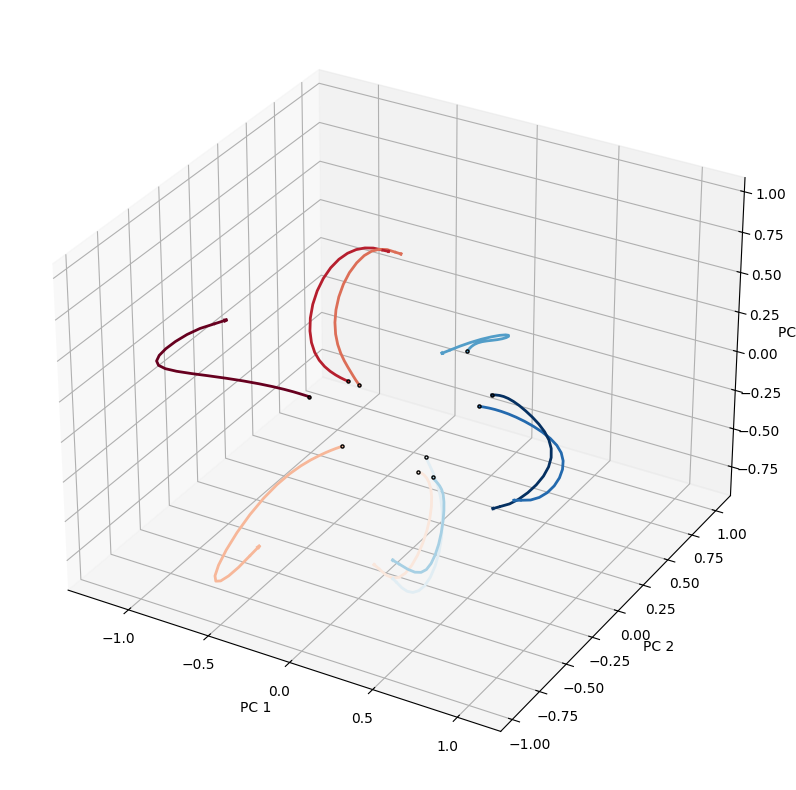

In [17]:
fig = plt.figure(figsize=(8, 8))
axis = fig.add_subplot(111, projection='3d')
plot_3d_projections(data_list[0:10], axis=axis, x_idx=0, y_idx=1, z_idx=2)

axis.set_xlabel('PC 1')
axis.set_ylabel('PC 2')
axis.set_zlabel('PC 3')
plt.tight_layout()
plt.show()

### Fit the dynamics

Try the unconstraint neural dynamics in the PCA space first. We assume the dynamics to be:

$$\dot{x} = Mx$$

where $\dot{x} = x(t+1) - x(t)$. Therefore, 

$$M = \argmin ||\dot{X} - MX||_F^2$$

Shape of X for Dynamics: (2160, 6)
Shape of X_dot for Dynamics: (2160, 6)


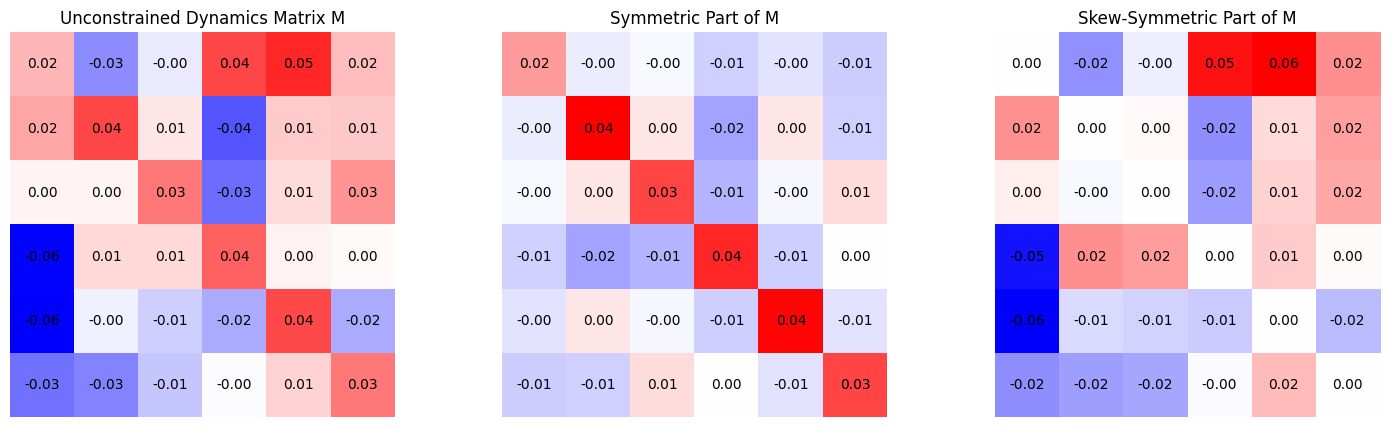

In [18]:
X = np.concatenate([x[:-1] for x in data_list])
print(f"Shape of X for Dynamics: {X.shape}")
X_dot = np.concatenate([np.diff(x, axis=0) for x in data_list])
print(f"Shape of X_dot for Dynamics: {X_dot.shape}")

# HACK: This might not be the best way to handle the last time point
# but this is how they did it in the original jPCA code, so we'll follow that for now.

# Unconstrained Dynamics
M = np.linalg.lstsq(X, X_dot, rcond=None)[0]

# Decomposing M into symmetric and skew-symmetric parts
M_symmetric = 0.5 * (M + M.T)
M_skew = 0.5 * (M - M.T)

# Plot the matrix M as a heatmap
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.imshow(M, cmap='bwr', vmin=-np.max(np.abs(M)), vmax=np.max(np.abs(M)))
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        plt.text(j, i, f"{M[i, j]:.2f}", ha='center', va='center', color='black')
plt.title("Unconstrained Dynamics Matrix M")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(M_symmetric, cmap='bwr', vmin=-np.max(np.abs(M_symmetric)), vmax=np.max(np.abs(M_symmetric)))
for i in range(M_symmetric.shape[0]):
    for j in range(M_symmetric.shape[1]):
        plt.text(j, i, f"{M_symmetric[i, j]:.2f}", ha='center', va='center', color='black')
plt.title("Symmetric Part of M")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(M_skew, cmap='bwr', vmin=-np.max(np.abs(M_skew)), vmax=np.max(np.abs(M_skew)))
for i in range(M_skew.shape[0]):
    for j in range(M_skew.shape[1]):
        plt.text(j, i, f"{M_skew[i, j]:.2f}", ha='center', va='center', color='black')
plt.title("Skew-Symmetric Part of M")
plt.axis('off')
plt.show()

In [19]:
# 5. eigen decompose (PCA space: V is D×D)
eigenvalues, V = np.linalg.eig(M_skew)
order = np.argsort(np.abs(np.imag(eigenvalues)), kind="stable")[::-1]
eigenvalues = eigenvalues[order]
V = V[:, order]
D = M_skew.shape[0]


/var/folders/q2/zn7rqp5s35d44q0_rbjdhnwm0000gn/T/ipykernel_24550/2403809417.py:8: RuntimeWarning: divide by zero encountered in matmul
  z = X @ w_plot
/var/folders/q2/zn7rqp5s35d44q0_rbjdhnwm0000gn/T/ipykernel_24550/2403809417.py:8: RuntimeWarning: overflow encountered in matmul
  z = X @ w_plot
/var/folders/q2/zn7rqp5s35d44q0_rbjdhnwm0000gn/T/ipykernel_24550/2403809417.py:8: RuntimeWarning: invalid value encountered in matmul
  z = X @ w_plot


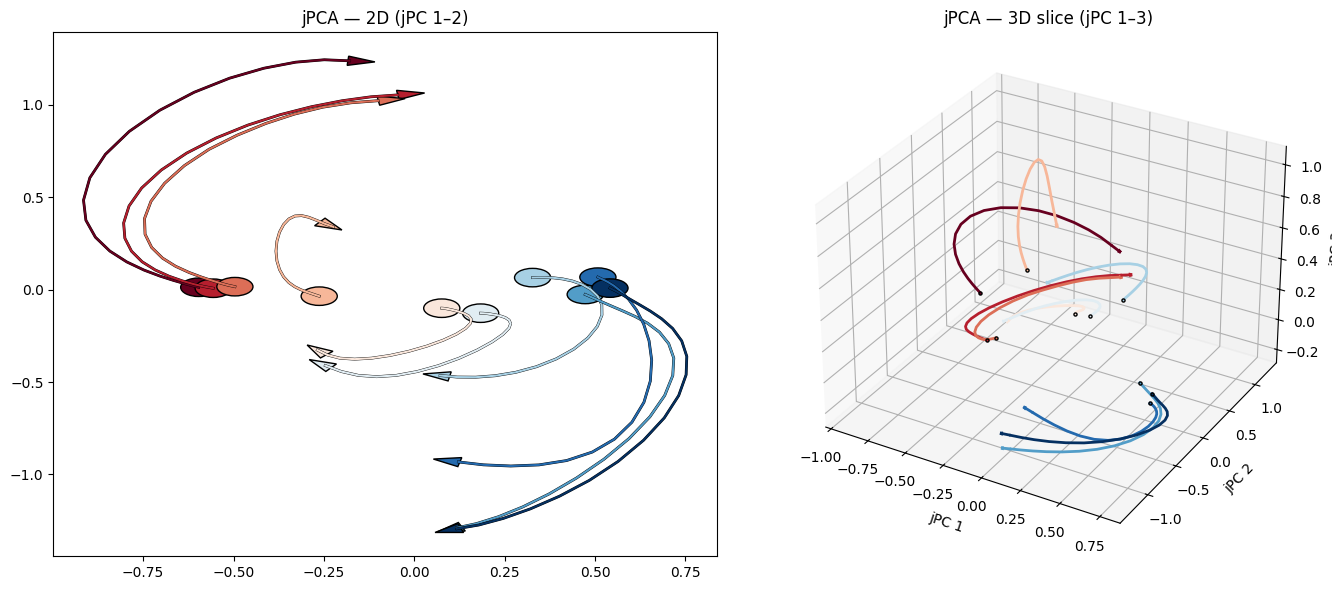

In [20]:
# 6. jPCA planes — full toolbox basis (num_jpcs>=3 for a 3D slice)
num_jpcs = 6
jp_scratch = JPCA(num_jpcs=num_jpcs)
jp_scratch.jpcs = jp_scratch._calculate_jpcs(M_skew)
jp_scratch.align_jpcs(data_list)
w_plot = jp_scratch.jpcs

z = X @ w_plot

projected_manual = [trial @ w_plot for trial in data_list]
fig = plt.figure(figsize=(14, 6))
ax2d = fig.add_subplot(1, 2, 1)
plot_projections(projected_manual[:10], axis=ax2d, x_idx=0, y_idx=1)
ax2d.set_title("jPCA — 2D (jPC 1–2)")
ax3d = fig.add_subplot(1, 2, 2, projection="3d")
plot_3d_projections(projected_manual[:10], axis=ax3d, x_idx=0, y_idx=1, z_idx=2)
ax3d.set_xlabel("jPC 1")
ax3d.set_ylabel("jPC 2")
ax3d.set_zlabel("jPC 3")
ax3d.set_title("jPCA — 3D slice (jPC 1–3)")
plt.tight_layout()
plt.show()




### Sliding windows — restricted epoch (−50 … 150 ms)

Slide a short **time segment** along the trial **using `data_list` from the preprocessing cell above** (21 bins). In each segment, stack states from **all conditions** (\(X\) from `x[:-1]`, \(\dot X\) from `np.diff`).


### Full epoch (−50 … 550 ms) — sliding-window \(M_{\mathrm{skew}}(t)\)

Separate preprocessing on **`times_full_axis`**: PCA is refit on **all 61 bins** (different subspace than the restricted epoch above). Then repeat local skew fits vs window center; results live in **`trajectory_full_skew_sym`** / **`data_list_full`** / **`times_full`**.


In [21]:
# full-span PCA + sliding fits (does not overwrite restricted `data_list` / `times`)
t0_full = int(times_full_axis[0])
t1_full = int(times_full_axis[-1])
data_list_full, full_data_var_long, pca_variance_captured_full = preprocess(
    data, times_full_axis, tstart=t0_full, tend=t1_full
)
sl = times_full_axis.index(t0_full)
su = times_full_axis.index(t1_full)
times_full = times_full_axis[sl : su + 1]

WINDOW_LEN_BINS_FULL = 5  # match restricted section or tune independently
STEP_BINS_FULL = 1
n_times_f = data_list_full[0].shape[0]
half_f = WINDOW_LEN_BINS_FULL // 2

# trajectory_full_lstq = []
trajectory_full_skew_sym = []

for center_bin in range(half_f, n_times_f - half_f, STEP_BINS_FULL):
    bins = bins_for_window(center_bin, WINDOW_LEN_BINS_FULL, n_times_f)
    X_w, Xdot_w = stack_XY_in_window(data_list_full, bins)
    # M_ls = np.linalg.lstsq(X_w, Xdot_w, rcond=None)[0]
    # M_skew_lstq = 0.5 * (M_ls - M_ls.T)
    # trajectory_full_lstq.append((center_bin, times_full[center_bin], M_skew_lstq))
    M_skew_symfit = skew_sym_regress(X_w, Xdot_w)
    trajectory_full_skew_sym.append((center_bin, times_full[center_bin], M_skew_symfit))

trajectory_full = trajectory_full_skew_sym  # alias for older text

print(f"full epoch: T={n_times_f} bins, {len(trajectory_full_skew_sym)} window fits (skew_sym_regress)")

M_skew_list = [Msk for _, _, Msk in trajectory_full_skew_sym]

print(len(M_skew_list), M_skew_list[0].shape)



/Users/emmiefitz-gibbon/Desktop/Time-varyingND/.venv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/emmiefitz-gibbon/Desktop/Time-varyingND/.venv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/emmiefitz-gibbon/Desktop/Time-varyingND/.venv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/emmiefitz-gibbon/Desktop/Time-varyingND/.venv/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/emmiefitz-gibbon/Desktop/Time-varyingND/.venv/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/emmiefitz-gibbon/Desktop/Time-

full epoch: T=61 bins, 57 window fits (lstq + skew_sym each)
57 (6, 6)


### Sliding-window \(M_{\mathrm{skew}}\) — fit quality & spectra vs time

**Eigenvalues.** Real skew \(M_{\mathrm{skew}}\) has purely imaginary conjugate pairs \(\pm i\omega\); \(\lvert\mathrm{Im}\,\lambda\rvert\) tracks dominant rotational frequencies (up to duplicates from conjugates).

**Residuals.** `skew_sym_regress` minimizes \(\|\dot{X} - X M^\top\|_F\) with \(M\) skew-symmetric (`jPCA/regression.py`); we plot per-window residuals using \(\dot{X} \approx X M^\top\).

Run after building **`trajectory_full_skew_sym`** (full-epoch sliding-window cell above).

Purple band marks **−50…150 ms**, the epoch used by the earlier restricted `preprocess` cell.


/var/folders/q2/zn7rqp5s35d44q0_rbjdhnwm0000gn/T/ipykernel_24550/3422769627.py:28: RuntimeWarning: divide by zero encountered in matmul
  pred = X_w @ M_win.T if pred_rhs_transpose else X_w @ M_win
/var/folders/q2/zn7rqp5s35d44q0_rbjdhnwm0000gn/T/ipykernel_24550/3422769627.py:28: RuntimeWarning: overflow encountered in matmul
  pred = X_w @ M_win.T if pred_rhs_transpose else X_w @ M_win
/var/folders/q2/zn7rqp5s35d44q0_rbjdhnwm0000gn/T/ipykernel_24550/3422769627.py:28: RuntimeWarning: invalid value encountered in matmul
  pred = X_w @ M_win.T if pred_rhs_transpose else X_w @ M_win


/var/folders/q2/zn7rqp5s35d44q0_rbjdhnwm0000gn/T/ipykernel_24550/3422769627.py:197: RuntimeWarning: divide by zero encountered in matmul
  pg = X_w @ M_skew_global.T if pred_rhs_transpose else X_w @ M_skew_global
/var/folders/q2/zn7rqp5s35d44q0_rbjdhnwm0000gn/T/ipykernel_24550/3422769627.py:197: RuntimeWarning: overflow encountered in matmul
  pg = X_w @ M_skew_global.T if pred_rhs_transpose else X_w @ M_skew_global
/var/folders/q2/zn7rqp5s35d44q0_rbjdhnwm0000gn/T/ipykernel_24550/3422769627.py:197: RuntimeWarning: invalid value encountered in matmul
  pg = X_w @ M_skew_global.T if pred_rhs_transpose else X_w @ M_skew_global
/var/folders/q2/zn7rqp5s35d44q0_rbjdhnwm0000gn/T/ipykernel_24550/3422769627.py:201: RuntimeWarning: divide by zero encountered in matmul
  X_w @ M_skew_global_secondary.T
/var/folders/q2/zn7rqp5s35d44q0_rbjdhnwm0000gn/T/ipykernel_24550/3422769627.py:201: RuntimeWarning: overflow encountered in matmul
  X_w @ M_skew_global_secondary.T
/var/folders/q2/zn7rqp5s35d44q0_

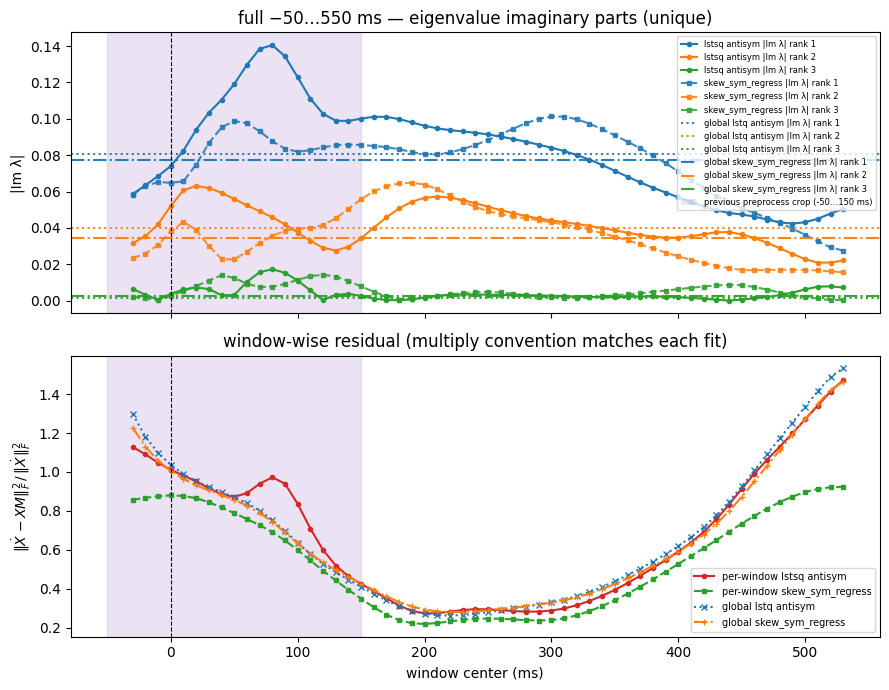

In [22]:
from matplotlib import patches as mpatches


def _skew_window_metrics(
    trajectory,
    data_list_local,
    times_axis,
    window_len_bins,
    top_k_eigs,
    pred_rhs_transpose,
):
    """per-window |Im λ| and normalized residual; pred is X @ M or X @ M.T."""
    if not trajectory:
        return None
    n_times_loc = len(times_axis)
    centers_ms = []
    omega_mat = np.full((len(trajectory), top_k_eigs), np.nan)
    rel_err = []

    for center_bin, center_ms, M_win in trajectory:
        centers_ms.append(center_ms)
        w = np.linalg.eigvals(M_win)
        im_sorted = np.sort(np.unique(np.round(np.abs(np.imag(w)), 12)))[::-1][:top_k_eigs]
        omega_mat[len(centers_ms) - 1, : len(im_sorted)] = im_sorted

        bins = bins_for_window(center_bin, window_len_bins, n_times_loc)
        X_w, Xdot_w = stack_XY_in_window(data_list_local, bins)
        pred = X_w @ M_win.T if pred_rhs_transpose else X_w @ M_win
        num = np.linalg.norm(Xdot_w - pred, ord="fro") ** 2
        den = np.linalg.norm(Xdot_w, ord="fro") ** 2
        rel_err.append(num / den if den > 0 else np.nan)

    return (
        np.asarray(centers_ms),
        omega_mat,
        np.asarray(rel_err),
    )


def diagnose_skew_trajectory(
    trajectory,
    data_list_local,
    times_axis,
    window_len_bins,
    title="",
    top_k_eigs=3,
    restrict_ms=(-50, 150),
    M_skew_global=None,
    M_skew_global_label="global fit (time-invariant)",
    pred_rhs_transpose=False,
    trajectory_secondary=None,
    M_skew_global_secondary=None,
    M_skew_global_secondary_label=None,
    pred_rhs_transpose_secondary=False,
    secondary_series_label="skew_sym_regress",
    primary_series_label="skew_sym_regress",
):
    """spectra + residuals vs window center; optional second trajectory (e.g. skew_sym_regress)."""
    if not trajectory:
        print("empty trajectory:", title)
        return

    pr = _skew_window_metrics(
        trajectory,
        data_list_local,
        times_axis,
        window_len_bins,
        top_k_eigs,
        pred_rhs_transpose,
    )
    if pr is None:
        return
    centers_ms, omega_primary, rel_primary = pr

    secondary = None
    if trajectory_secondary is not None:
        secondary = _skew_window_metrics(
            trajectory_secondary,
            data_list_local,
            times_axis,
            window_len_bins,
            top_k_eigs,
            pred_rhs_transpose_secondary,
        )

    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    if restrict_ms is not None:
        lo, hi = restrict_ms
        for ax in axes:
            ax.axvspan(lo, hi, alpha=0.18, color="tab:purple", zorder=0)

    for k in range(top_k_eigs):
        axes[0].plot(
            centers_ms,
            omega_primary[:, k],
            "-o",
            ms=3,
            color=f"C{k}",
            label=f"{primary_series_label} |Im λ| rank {k+1}",
        )

    if secondary is not None:
        _, omega_sec, _ = secondary
        for k in range(top_k_eigs):
            axes[0].plot(
                centers_ms,
                omega_sec[:, k],
                "--s",
                ms=3,
                color=f"C{k}",
                alpha=0.85,
                label=f"{secondary_series_label} |Im λ| rank {k+1}",
            )

    if M_skew_global is not None:
        wg = np.linalg.eigvals(M_skew_global)
        im_g = np.sort(np.unique(np.round(np.abs(np.imag(wg)), 12)))[::-1][:top_k_eigs]
        for k in range(top_k_eigs):
            if k >= len(im_g) or np.isnan(im_g[k]):
                continue
            axes[0].axhline(
                im_g[k],
                color=f"C{k}",
                ls=":",
                lw=1.5,
                alpha=0.95,
                label=f"{M_skew_global_label} |Im λ| rank {k+1}",
            )

    if M_skew_global_secondary is not None:
        wg2 = np.linalg.eigvals(M_skew_global_secondary)
        im_g2 = np.sort(np.unique(np.round(np.abs(np.imag(wg2)), 12)))[::-1][:top_k_eigs]
        for k in range(top_k_eigs):
            if k >= len(im_g2) or np.isnan(im_g2[k]):
                continue
            axes[0].axhline(
                im_g2[k],
                color=f"C{k}",
                ls="-.",
                lw=1.5,
                alpha=0.95,
                label=f"{M_skew_global_secondary_label} |Im λ| rank {k+1}",
            )

    axes[0].set_ylabel("|Im λ|")
    axes[0].set_title(title + " — eigenvalue imaginary parts (unique)")
    axes[0].axvline(0, color="k", ls="--", lw=0.8, zorder=2)

    leg_handles, leg_labels = axes[0].get_legend_handles_labels()
    if restrict_ms is not None:
        lo, hi = restrict_ms
        leg_handles.append(
            mpatches.Patch(
                facecolor="tab:purple",
                alpha=0.18,
                edgecolor="none",
                label=f"previous preprocess crop ({lo}…{hi} ms)",
            )
        )
    axes[0].legend(handles=leg_handles, fontsize=6, loc="best")

    axes[1].plot(
        centers_ms,
        rel_primary,
        color="C3",
        marker="o",
        ms=3,
        ls="-",
        label=f"per-window {primary_series_label}",
    )

    if secondary is not None:
        _, _, rel_sec = secondary
        axes[1].plot(
            centers_ms,
            rel_sec,
            color="C2",
            marker="s",
            ms=3,
            ls="--",
            label=f"per-window {secondary_series_label}",
        )

        # global residuals on same windows (fair comparison)
        rel_globs_pri = []
        rel_globs_sec = []
        for i, (center_bin, _cms, _) in enumerate(trajectory):
            bins = bins_for_window(center_bin, window_len_bins, len(times_axis))
            X_w, Xdot_w = stack_XY_in_window(data_list_local, bins)
            den = np.linalg.norm(Xdot_w, ord="fro") ** 2
            if den <= 0:
                rel_globs_pri.append(np.nan)
                rel_globs_sec.append(np.nan)
                continue
            if M_skew_global is not None:
                pg = X_w @ M_skew_global.T if pred_rhs_transpose else X_w @ M_skew_global
                rel_globs_pri.append(np.linalg.norm(Xdot_w - pg, ord="fro") ** 2 / den)
            if M_skew_global_secondary is not None:
                ps = (
                    X_w @ M_skew_global_secondary.T
                    if pred_rhs_transpose_secondary
                    else X_w @ M_skew_global_secondary
                )
                rel_globs_sec.append(np.linalg.norm(Xdot_w - ps, ord="fro") ** 2 / den)

        if M_skew_global is not None and rel_globs_pri:
            axes[1].plot(
                centers_ms,
                rel_globs_pri,
                color="C0",
                ls=":",
                lw=1.5,
                marker="x",
                ms=4,
                label=M_skew_global_label,
            )
        if M_skew_global_secondary is not None and any(np.isfinite(rel_globs_sec)):
            axes[1].plot(
                centers_ms,
                rel_globs_sec,
                color="C1",
                ls="-.",
                lw=1.5,
                marker="+",
                ms=5,
                label=M_skew_global_secondary_label,
            )
    else:
        # original single-series global residual overlay
        if M_skew_global is not None:
            rel_err_global = []
            for i, (center_bin, _cms, _) in enumerate(trajectory):
                bins = bins_for_window(center_bin, window_len_bins, len(times_axis))
                X_w, Xdot_w = stack_XY_in_window(data_list_local, bins)
                pred_g = X_w @ M_skew_global.T if pred_rhs_transpose else X_w @ M_skew_global
                den = np.linalg.norm(Xdot_w, ord="fro") ** 2
                numg = np.linalg.norm(Xdot_w - pred_g, ord="fro") ** 2
                rel_err_global.append(numg / den if den > 0 else np.nan)
            axes[1].plot(
                centers_ms,
                rel_err_global,
                color="C0",
                marker="s",
                ms=3,
                label=M_skew_global_label,
            )

    axes[1].set_ylabel(r"$\|\dot X - XM\|_F^2 \,/\, \|\dot X\|_F^2$")
    axes[1].set_title("window-wise residual (multiply convention matches each fit)")
    axes[1].axvline(0, color="k", ls="--", lw=0.8, zorder=2)
    axes[1].set_xlabel("window center (ms)")
    axes[1].legend(fontsize=7, loc="best")

    plt.tight_layout()
    plt.show()


need = ("trajectory_full_skew_sym", "WINDOW_LEN_BINS_FULL")
if any(k not in globals() for k in need):
    print("run the full-epoch sliding-window cell first")
elif not globals().get("trajectory_full_skew_sym"):
    print("empty trajectories — rerun sliding-window cell")
else:
    Xgf = np.concatenate([x[:-1] for x in data_list_full])
    Xdgf = np.concatenate([np.diff(x, axis=0) for x in data_list_full])
    # Mga = np.linalg.lstsq(Xgf, Xdgf, rcond=None)[0]
    # M_skew_global_lstq = 0.5 * (Mga - Mga.T)
    M_skew_global_skew_sym = skew_sym_regress(Xgf, Xdgf)
    diagnose_skew_trajectory(
        trajectory_full_skew_sym,
        data_list_full,
        times_full,
        WINDOW_LEN_BINS_FULL,
        title="full −50…550 ms",
        M_skew_global=M_skew_global_skew_sym,
        M_skew_global_label="global skew_sym_regress",
        pred_rhs_transpose=True,
        primary_series_label="skew_sym_regress",
    )
